# 05 — Cross-Impact Balance (CIB) Matrix\n\nPairwise evaluation: How does progress in Driver A affect Driver B?\nScale: -3 (strongly inhibits) to +3 (strongly promotes)\nEach assessment includes reasoning + source references.

In [1]:
import sys, os, json
import numpy as np
sys.path.insert(0, os.path.abspath(".."))

from src.config import CHROMA_PERSIST_DIR, MAX_RAG_CHUNKS, CIB_MODEL
from src.llm import embed, safe_chat_json
from src.traceability import TechDriver, CIBEntry, KBPool
from src import prompts

import chromadb
client = chromadb.PersistentClient(path=CHROMA_PERSIST_DIR)
collection = client.get_collection("knowledge_base")

with open("../data/outputs/merge_state.json") as f:
    merge_state = json.load(f)
all_drivers = [TechDriver(**d) for d in merge_state["unified_drivers"]]

# use ALL drivers — no cap
drivers = list(all_drivers)

print(f"All drivers: {len(all_drivers)} → Selected for CIB: {len(drivers)} (ALL)")
print(f"CIB pairs: {len(drivers) * (len(drivers) - 1)}")
print(f"Using model: {CIB_MODEL}")
print()
for d in drivers:
    tag = {"both": "VAL", "bom": "BOM", "trend": "TRD"}[d.origin.value]
    print(f"  [{tag}] {d.name[:60]}")

All drivers: 14 → Selected for CIB: 14 (ALL)
CIB pairs: 182
Using model: gpt-4.1

  [VAL] Ultra Wideband RF Frontend and Millimeter-Wave/Sub-THz Spect
  [VAL] High Sensitivity Receiver and Quantum RF Sensing with Rydber
  [VAL] Real-Time Digitizer and Photonic Signal Processing for Ultra
  [VAL] Panorama Scan Engine and Shift to Continuous, Automated, Rea
  [VAL] I/Q Data Streaming Interface and Edge Computing for Distribu
  [VAL] Direction Finding Module and Space-Based Spectrum Monitoring
  [VAL] AI-Driven Spectrum Sensing, Prediction, and Dynamic Spectrum
  [TRD] Federated Learning and Energy-Efficient AI Architectures for
  [TRD] AI-Enabled Software-Defined Radio (SDR) and Open Radio Acces
  [TRD] Dynamic Spectrum Sharing and Real-Time Automated Environment
  [TRD] AI-Native 6G Networks with Embedded Spectrum Sensing
  [TRD] Cross-Border and Harmonized Spectrum Monitoring Coordination
  [TRD] Increasing Cybersecurity Requirements for Monitoring Infrast
  [TRD] Digital Twin Networks

In [2]:
def retrieve_for_pair(driver_a: str, driver_b: str, n: int = 3) -> str:
    query = f"{driver_a} {driver_b} relationship impact influence"
    query_emb = embed([query])[0]
    results = collection.query(query_embeddings=[query_emb], n_results=n, include=["documents", "metadatas"])
    parts = []
    for i in range(len(results["ids"][0])):
        parts.append(f"[Chunk ID: {results['ids'][0][i]}] (Source: {results['metadatas'][0][i]['source_title']})\n{results['documents'][0][i]}")
    return "\n\n---\n\n".join(parts)

# evaluate all pairs using CIB_MODEL
cib_entries: list[CIBEntry] = []
n = len(drivers)
matrix = np.zeros((n, n), dtype=int)

for i, da in enumerate(drivers):
    for j, db in enumerate(drivers):
        if i == j:
            continue
        rag_text = retrieve_for_pair(da.name, db.name)
        prompt = prompts.CIB_EVALUATE.format(
            driver_a_name=da.name, driver_a_description=da.description[:200],
            driver_b_name=db.name, driver_b_description=db.description[:200],
            rag_chunks=rag_text,
        )
        result = safe_chat_json(prompt, system="You are evaluating cross-impacts between technology drivers in spectrum monitoring.", model=CIB_MODEL, temperature=0.2)

        pro = max(0, min(3, result.get("promoting_score", 0)))
        inh = max(0, min(3, result.get("inhibiting_score", 0)))
        score = max(-3, min(3, pro - inh))
        matrix[i][j] = score

        reasoning = f"Pro({pro}): {result.get('promoting_reasoning', '')} | Inh({inh}): {result.get('inhibiting_reasoning', '')}"
        entry = CIBEntry(
            driver_a_id=da.id, driver_b_id=db.id,
            impact_score=score, reasoning=reasoning,
            source_chunk_ids=result.get("source_chunk_ids_used", []),
        )
        cib_entries.append(entry)

    print(f"  Row {i+1}/{n}: {da.name[:40]} → scores: {matrix[i].tolist()}")

# score distribution analysis
all_scores = [matrix[i][j] for i in range(n) for j in range(n) if i != j]
from collections import Counter
dist = Counter(all_scores)
print(f"\n=== Score Distribution ===")
for s in range(-3, 4):
    count = dist.get(s, 0)
    pct = count / len(all_scores) * 100
    bar = "█" * int(pct / 2)
    print(f"  {s:+d}: {count:3d} ({pct:4.1f}%) {bar}")
neg_count = sum(1 for s in all_scores if s < 0)
print(f"\nNegative scores: {neg_count}/{len(all_scores)} ({neg_count/len(all_scores)*100:.1f}%)")
print(f"Mean score: {np.mean(all_scores):.2f}")

  Row 1/14: Ultra Wideband RF Frontend and Millimete → scores: [0, -1, 1, 0, 1, 1, 2, 1, 2, 1, 0, 1, 1, 1]


  Row 2/14: High Sensitivity Receiver and Quantum RF → scores: [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1]


  Row 3/14: Real-Time Digitizer and Photonic Signal  → scores: [1, -1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


  Row 4/14: Panorama Scan Engine and Shift to Contin → scores: [1, -1, -1, 0, -1, 0, 1, 1, 1, 0, 0, 1, 1, 1]


  Row 5/14: I/Q Data Streaming Interface and Edge Co → scores: [1, -1, -1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1]


...

  Row 10/14: Dynamic Spectrum Sharing and Real-Time A → scores: [0, -1, 1, 0, 0, -1, 1, 1, 1, 0, -1, 1, 1, 0]


  Row 11/14: AI-Native 6G Networks with Embedded Spec → scores: [-1, -1, -1, -1, -1, -1, 0, -1, 0, -1, 0, -1, 0, 0]


  Row 12/14: Cross-Border and Harmonized Spectrum Mon → scores: [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, -1, 0, 1, 1]


  Row 13/14: Increasing Cybersecurity Requirements fo → scores: [0, -1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


  Row 14/14: Digital Twin Networks for Spectrum Monit → scores: [1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0]

=== Score Distribution ===
  -3:   0 ( 0.0%) 
  -2:   0 ( 0.0%) 
  -1:  33 (18.1%) █████████
  +0:  57 (31.3%) ███████████████
  +1:  90 (49.5%) ████████████████████████
  +2:   2 ( 1.1%) 
  +3:   0 ( 0.0%) 

Negative scores: 33/182 (18.1%)
Mean score: 0.34


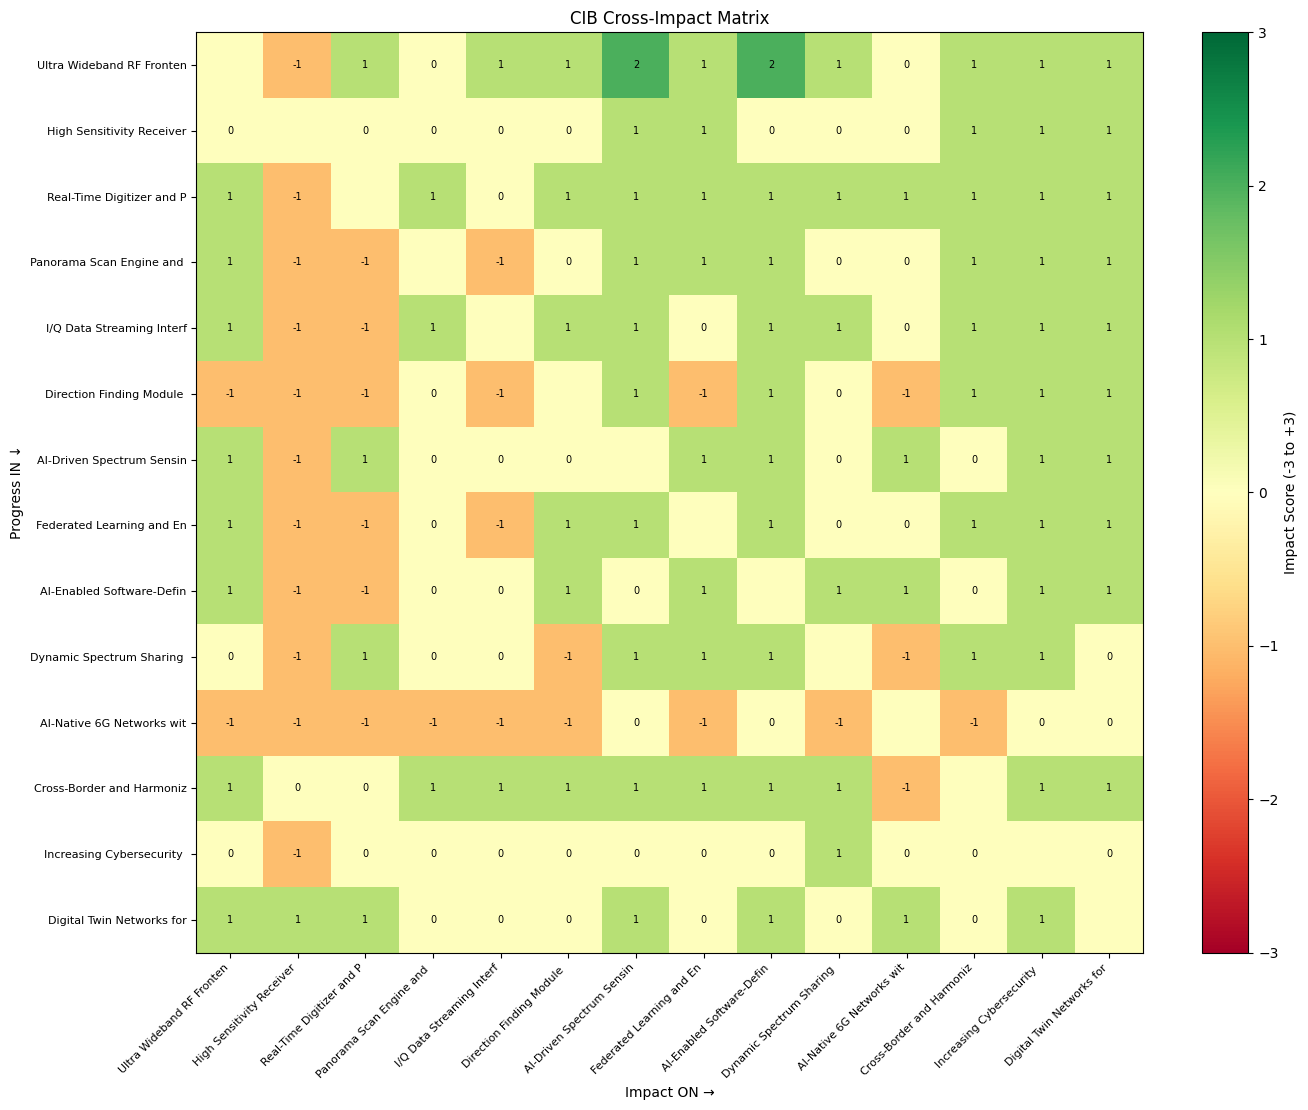


=== Driver Influence Ranking ===
  Influence: +11 | Dependence:  +6 | Ultra Wideband RF Frontend and Millimeter-Wave/Sub-THz Spectrum Monitoring
  Influence: +10 | Dependence:  -2 | Real-Time Digitizer and Photonic Signal Processing for Ultra-Wideband Monitoring
  Influence:  +9 | Dependence:  +7 | Cross-Border and Harmonized Spectrum Monitoring Coordination
  Influence:  +7 | Dependence: +10 | Digital Twin Networks for Spectrum Monitoring
  Influence:  +7 | Dependence:  -2 | I/Q Data Streaming Interface and Edge Computing for Distributed Spectrum Monitoring
  Influence:  +6 | Dependence: +11 | AI-Driven Spectrum Sensing, Prediction, and Dynamic Spectrum Access in Cognitive Radio Networks
  Influence:  +5 | Dependence: +11 | AI-Enabled Software-Defined Radio (SDR) and Open Radio Access Networks (ORAN) Modular Architectures
  Influence:  +5 | Dependence: -10 | High Sensitivity Receiver and Quantum RF Sensing with Rydberg Atoms
  Influence:  +4 | Dependence:  +6 | Federated Learning and

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(max(8, n), max(6, n * 0.8)))
labels = [d.name[:25] for d in drivers]

im = ax.imshow(matrix, cmap="RdYlGn", vmin=-3, vmax=3, aspect="auto")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Impact ON →")
ax.set_ylabel("Progress IN ↓")
ax.set_title("CIB Cross-Impact Matrix")

for i in range(n):
    for j in range(n):
        if i != j:
            ax.text(j, i, str(matrix[i][j]), ha="center", va="center", fontsize=7)

plt.colorbar(im, label="Impact Score (-3 to +3)")
plt.tight_layout()
plt.savefig("../data/outputs/cib_matrix.png", dpi=150)
plt.show()

# influence analysis
influence = matrix.sum(axis=1)  # how much does this driver influence others
dependence = matrix.sum(axis=0)  # how much is this driver influenced by others

print("\n=== Driver Influence Ranking ===")
for idx in np.argsort(influence)[::-1]:
    d = drivers[idx]
    print(f"  Influence: {influence[idx]:+3d} | Dependence: {dependence[idx]:+3d} | {d.name}")

In [4]:
# save CIB state
cib_state = {
    "matrix": matrix.tolist(),
    "driver_ids": [d.id for d in drivers],
    "driver_names": [d.name for d in drivers],
    "entries": [e.model_dump(mode="json") for e in cib_entries],
    "influence": {drivers[i].id: int(influence[i]) for i in range(n)},
    "dependence": {drivers[i].id: int(dependence[i]) for i in range(n)},
}
with open("../data/outputs/cib_state.json", "w") as f:
    json.dump(cib_state, f, indent=2)
print(f"Saved CIB matrix ({n}x{n}) with {len(cib_entries)} entries")

Saved CIB matrix (14x14) with 182 entries
